# Human-AI Deferral on CIFAR-10H
## Symbolic and Evolutionary Artificial Intelligence project,
### *Artificial Intelligence and Data Engineering course*, *University of Pisa*
### **Authors:** Tommaso Falaschi, Rossana Antonella Sacco
The original code is available here: https://github.com/clinicalml/human_ai_deferral

All the resources of this notebook are available at: https://github.com/LeBonWskii/SEAI-Project/tree/main/learning2defer-cifar10h



## General problem: reliable prediction under uncertainty

In many real-world applications, a machine learning model should not be forced to make a prediction on every input. When uncertainty is high, it can be preferable to **abstain** or **defer** the decision rather than risk a confident mistake. The system aims to improve reliability by making predictions only on the examples it can handle well, while treating difficult cases differently.

## Learning to Defer

A particularly important setting is **Learning to Defer (L2D)**. In this scenario, abstention is not just a rejection of the prediction: instead, the model can explicitly **defer the input to an external expert**, such as a human annotator. The goal is therefore not simply to maximize the model’s standalone accuracy, but to optimize the performance of the **combined human-AI system**. In other words, the model should learn when it is better to predict by itself and when it is better to leave the decision to the human expert.


This notebook implements a practical Learning to Defer pipeline on **CIFAR-10H**, a variant of CIFAR-10 enriched with human label distributions. Unlike standard **CIFAR-10**, where each image is associated with a single ground truth class label, **CIFAR-10H** provides, for each image, a distribution of human annotations collected from multiple annotators. This makes it possible to model not only the true label, but also the variability and uncertainty of human decisions. In this notebook, those human label distributions are used to simulate a human expert, which is essential for studying how the model should decide whether to predict by itself or defer the input to a human.

More specifically:
1. **Pretrains a ResNet-18 backbone on CIFAR-10** as a standard image classifier.
2. **Extends the classifier from 10 to 11 outputs**, where the extra output represents the decision to **defer to the human**.
3. Uses **CIFAR-10H human annotations** to simulate a human expert for each image.
4. Trains a **Realizable Surrogate** model that learns both classification and deferral behavior.
5. Selects the best operating configuration on the validation set by tuning:
   - the deferral loss trade-off parameter `alpha`
   - the rejection threshold used to decide when to defer.
6. Evaluates the final system on the test set using metrics such as:
   - classifier accuracy
   - human accuracy
   - coverage
   - accuracy on non-deferred samples
   - human accuracy on deferred samples
   - overall **system accuracy**



In [ ]:
import os
import copy
import math
import random
import json
import requests
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score

## Configuration overview

The main parameter used are the following:

- **`PRETRAIN_EPOCHS = 120`**  
  Number of epochs used to train the standard CIFAR-10 classifier. This value is large enough to obtain a strong backbone without making the training excessively long.

- **`DEFER_EPOCHS = 80`**  
  Number of epochs used for the Learning to Defer phase. Since only the final layer is trained when the backbone is frozen, fewer epochs are usually sufficient.

- **`PRETRAIN_LR = 1e-3`**  
  Learning rate for the backbone pretraining stage. This is a standard value for AdamW and usually provides stable optimization.

- **`DEFER_LR = 3e-3`**  
  Learning rate for the deferral phase. A slightly larger value is used because, with a frozen backbone, only the final layer must adapt, so optimization can be faster.

- **`WEIGHT_DECAY = 1e-4`**  
  Regularization coefficient used to reduce overfitting and keep the learned weights well-controlled.

- **`FREEZE_BACKBONE = True`**  
  The pretrained feature extractor is frozen during the deferral phase, so only the final deferral layer is updated. This makes training faster, more stable, and closer to a transfer learning setting.

- **`ALPHA_GRID = [0.0, 0.1, 0.3, 0.5, 0.9, 1.0]`**  
  Candidate values for the trade-off parameter `alpha`, which balances standard classification loss and the surrogate deferral loss. The best value is selected on the validation set.


In [ ]:
SEED = 42

DATA_DIR = "/content/data"
CKPT_DIR = "/content/checkpoints"
FIGURES_DIR = "/content/figures"
RESULTS_DIR = "/content/results"

BACKBONE_CKPT = os.path.join(CKPT_DIR, "cifar10_backbone_resnet18.pt")
DEFER_CKPT = os.path.join(CKPT_DIR, "cifar10h_realizable_surrogate_resnet18.pt")

FINAL_METRICS_JSON = os.path.join(RESULTS_DIR, "final_metrics.json")
SUMMARY_METRICS_JSON = os.path.join(RESULTS_DIR, "summary_metrics.json")

BATCH_SIZE_PRETRAIN = 128
BATCH_SIZE_DEFER = 128

PRETRAIN_EPOCHS = 120
DEFER_EPOCHS = 80

PRETRAIN_LR = 1e-3
DEFER_LR = 3e-3

WEIGHT_DECAY = 1e-4
FREEZE_BACKBONE = True

ALPHA_GRID = [0.0, 0.1, 0.3, 0.5, 0.9, 1.0]

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


FORCE_TRAIN = False
# True  -> always train locally, never download from GitHub
# False -> never train, only load locally or download from GitHub repo


GITHUB_USER = "LeBonWskii"
GITHUB_REPO = "SEAI-Project"
GITHUB_BRANCH = "main"
GITHUB_SUBDIR = "learning2defer-cifar10h"


GITHUB_RAW_BASE = (
    f"https://raw.githubusercontent.com/{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_BRANCH}/{GITHUB_SUBDIR}"
)

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)


REMOTE_ASSETS = {
    "backbone_ckpt": f"{GITHUB_RAW_BASE}/checkpoints/cifar10_backbone_resnet18.pt",
    "defer_ckpt": f"{GITHUB_RAW_BASE}/checkpoints/cifar10h_realizable_surrogate_resnet18.pt",
    "final_metrics_json": f"{GITHUB_RAW_BASE}/results/final_metrics.json",
    "summary_metrics_json": f"{GITHUB_RAW_BASE}/results/summary_metrics.json",
    "coverage_plot": f"{GITHUB_RAW_BASE}/figures/coverage_vs_system_accuracy.png",
    "human_vs_clf_plot": f"{GITHUB_RAW_BASE}/figures/human_vs_classifier_operational_split.png",
}

print("Device:", device)
print("FORCE_TRAIN:", FORCE_TRAIN)
print("Backbone checkpoint:", BACKBONE_CKPT)
print("Defer checkpoint:", DEFER_CKPT)
print("Figures directory:", FIGURES_DIR)
print("Results directory:", RESULTS_DIR)
print("Run ID:", RUN_ID)
print("GitHub raw base:", GITHUB_RAW_BASE)

Device: cuda
FORCE_TRAIN: False
Backbone checkpoint: /content/checkpoints/cifar10_backbone_resnet18.pt
Defer checkpoint: /content/checkpoints/cifar10h_realizable_surrogate_resnet18.pt
Figures directory: /content/figures
Results directory: /content/results
Run ID: 20260409_210507
GitHub raw base: https://raw.githubusercontent.com/LeBonWskii/SEAI-Project/main/learning2defer-cifar10h


In [ ]:
def download_file(url, out_path, timeout=120):
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    try:
        print(f"Downloading from GitHub repo: {url}")
        r = requests.get(url, allow_redirects=True, timeout=timeout)
        r.raise_for_status()
        with open(out_path, "wb") as f:
            f.write(r.content)
        print(f"Downloaded: {out_path}")
        return True
    except Exception as e:
        print(f"Download failed for {url}: {e}")
        return False


def ensure_local_asset(local_path, remote_url=None, kind="asset"):
    if os.path.exists(local_path):
        print(f"Local {kind} found: {local_path}")
        return True

    if FORCE_TRAIN:
        print(f"{kind.capitalize()} not found locally, but FORCE_TRAIN=True so download is skipped.")
        return False

    if remote_url is not None:
        ok = download_file(remote_url, local_path)
        if ok:
            print(f"{kind.capitalize()} downloaded from GitHub.")
            return True

    print(f"{kind.capitalize()} not available locally or on GitHub: {local_path}")
    return False


def save_current_figure(filename, close=True, dpi=150):
    path = os.path.join(FIGURES_DIR, filename)
    plt.savefig(path, bbox_inches="tight", dpi=dpi)
    print("Figure saved to:", path)
    if close:
        plt.close()
    return path


def _to_python_scalar(v):
    if isinstance(v, (np.floating, np.float32, np.float64)):
        return float(v)
    if isinstance(v, (np.integer, np.int32, np.int64)):
        return int(v)
    return v


def save_metrics_json(filename, payload):
    path = os.path.join(RESULTS_DIR, filename)

    def convert(obj):
        if isinstance(obj, dict):
            return {k: convert(v) for k, v in obj.items()}
        if isinstance(obj, list):
            return [convert(v) for v in obj]
        if isinstance(obj, tuple):
            return [convert(v) for v in obj]
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return _to_python_scalar(obj)

    payload = convert(payload)

    with open(path, "w") as f:
        json.dump(payload, f, indent=2)

    print("Metrics JSON saved to:", path)
    return path


def preload_remote_artifacts():
    if FORCE_TRAIN:
        print("FORCE_TRAIN=True -> artifact download skipped.")
        return

    ensure_local_asset(
        FINAL_METRICS_JSON,
        REMOTE_ASSETS["final_metrics_json"],
        kind="metrics json",
    )
    ensure_local_asset(
        SUMMARY_METRICS_JSON,
        REMOTE_ASSETS["summary_metrics_json"],
        kind="summary metrics json",
    )
    ensure_local_asset(
        os.path.join(FIGURES_DIR, "coverage_vs_system_accuracy.png"),
        REMOTE_ASSETS["coverage_plot"],
        kind="coverage plot",
    )
    ensure_local_asset(
        os.path.join(FIGURES_DIR, "human_vs_classifier_operational_split.png"),
        REMOTE_ASSETS["human_vs_clf_plot"],
        kind="human vs classifier plot",
    )

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

## Input preprocessing and data augmentation

First of all we define the preprocessing pipeline applied to CIFAR images before they are fed into the model.

- **`CIFAR_MEAN` and `CIFAR_STD`**  
  These are the channel-wise mean and standard deviation values of the CIFAR dataset, rescaled to the `[0,1]` range. They are used to normalize the input images so that each channel has a more stable scale during training.

- **`train_tf`**  
  During training the pipeline includes both preprocessing and data augmentation:
  - **`RandomCrop(32, padding=4, padding_mode="reflect")`**: slightly shifts the image by padding it and then randomly cropping back to `32×32`. This improves robustness to small translations.
  - **`RandomHorizontalFlip()`**: randomly flips the image horizontally, increasing variability in the training set.
  - **`ToTensor()`**: converts the image into a PyTorch tensor and rescales pixel values from `[0,255]` to `[0,1]`.
  - **`Normalize(CIFAR_MEAN, CIFAR_STD)`**: standardizes the image channels using the dataset statistics.

- **`test_tf`**  
  This transformation pipeline is used for validation and test data. It only includes:
  - conversion to tensor
  - normalization

  No random augmentation is applied at evaluation time, so that results remain stable and reproducible.


In [ ]:
CIFAR_MEAN = [125.3 / 255.0, 123.0 / 255.0, 113.9 / 255.0]
CIFAR_STD  = [63.0 / 255.0, 62.1 / 255.0, 66.7 / 255.0]

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode="reflect"),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

## Custom dataset classes
We use two custom PyTorch datasets classes:


### `ImageLabelDataset`

This dataset is used for **standard image classification**.

- It stores:
  - the input images
  - the corresponding ground-truth labels
  - an optional transformation pipeline


### `ImageHumanDataset`

This dataset extends `ImageLabelDataset` to support the **human-AI** case, where human predictions are available alongside ground-truth labels.

- In addition to the previous dataset it store the predictions provided by a human expert




In [ ]:
class ImageLabelDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = np.array(images)
        self.labels = np.array(labels, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        if self.transform is not None:
            img = self.transform(img)
        label = int(self.labels[idx])
        return img, label


class ImageHumanDataset(Dataset):
    def __init__(self, images, labels, hum_preds, transform=None):
        self.images = np.array(images)
        self.labels = np.array(labels, dtype=np.int64)
        self.hum_preds = np.array(hum_preds, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        if self.transform is not None:
            img = self.transform(img)
        label = int(self.labels[idx])
        hum_pred = int(self.hum_preds[idx])
        return img, label, hum_pred

In [ ]:
def download_cifar10h_probs(data_dir=DATA_DIR):
    url = f"{GITHUB_RAW_BASE}/cifar10h-probs.npy"
    out_path = os.path.join(data_dir, "cifar10h-probs.npy")

    if not os.path.exists(out_path):
        print("Downloading cifar10h-probs.npy...")
        r = requests.get(url, allow_redirects=True, timeout=60)
        r.raise_for_status()
        with open(out_path, "wb") as f:
            f.write(r.content)
        print("Download completed.")
    else:
        print("cifar10h-probs.npy already present.")

    return out_path

## Data loader construction

There are two dataloaders used in the main stages:

- **`build_cifar10h_loaders(...)`** creates the dataloaders for the **Learning to Defer phase** on CIFAR-10H. It loads the human label probability distributions, generates a simulated human prediction for each image, splits the dataset into training, validation, and test sets, and returns dataloaders built with `ImageHumanDataset`.

  The human predictions are not taken as a fixed label. Instead, for each image, we sample **one simulated human decision** from the corresponding CIFAR-10H probability distribution. This is done by drawing from a multinomial distribution whose probabilities are given by `human_probs[i]`, and then selecting the sampled class. In this way, the human expert is modeled as **stochastic rather than deterministic**, which better reflects the variability observed in real human annotations.

- **`build_cifar10_pretrain_loaders(...)`** creates the dataloaders for the **standard CIFAR-10 pretraining phase**. It loads the CIFAR-10 training set, randomly splits it into training and validation subsets, applies the appropriate transformations, and returns the corresponding PyTorch dataloaders.





In [ ]:
def build_cifar10h_loaders(
    data_dir=DATA_DIR,
    batch_size=128,
    test_split=0.2,
    val_split=0.1,
    seed=42,
    use_data_aug=False,
):
    probs_path = download_cifar10h_probs(data_dir)
    human_probs = np.load(probs_path)

    cifar10_test = datasets.CIFAR10(root=data_dir, train=False, download=True)
    images = np.array(cifar10_test.data)
    labels = np.array(cifar10_test.targets, dtype=np.int64)

    assert len(images) == len(labels) == len(human_probs), "Dimensions non correct"

    rng = np.random.default_rng(seed)
    hum_preds = np.array(
        [rng.multinomial(1, pvals=human_probs[i]).argmax() for i in range(len(human_probs))],
        dtype=np.int64,
    )

    n = len(images)
    idx = np.arange(n)
    rng.shuffle(idx)

    test_size = int(test_split * n)
    val_size = int(val_split * n)
    train_size = n - test_size - val_size

    train_idx = idx[:train_size]
    val_idx   = idx[train_size:train_size + val_size]
    test_idx  = idx[train_size + val_size:]

    tf_train = train_tf if use_data_aug else test_tf

    ds_train = ImageHumanDataset(images[train_idx], labels[train_idx], hum_preds[train_idx], transform=tf_train)
    ds_val   = ImageHumanDataset(images[val_idx],   labels[val_idx],   hum_preds[val_idx],   transform=test_tf)
    ds_test  = ImageHumanDataset(images[test_idx],  labels[test_idx],  hum_preds[test_idx],  transform=test_tf)

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    human_acc = accuracy_score(hum_preds, labels)

    info = {
        "n_total": n,
        "n_train": len(ds_train),
        "n_val": len(ds_val),
        "n_test": len(ds_test),
        "human_all_acc": human_acc,
    }

    return train_loader, val_loader, test_loader, info

In [ ]:
def build_cifar10_pretrain_loaders(
    data_dir=DATA_DIR,
    batch_size=128,
    val_split=0.1,
    seed=42,
):
    cifar10_train = datasets.CIFAR10(root=data_dir, train=True, download=True)
    images = np.array(cifar10_train.data)
    labels = np.array(cifar10_train.targets, dtype=np.int64)

    n = len(images)
    idx = np.arange(n)
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)

    val_size = int(val_split * n)
    train_size = n - val_size

    train_idx = idx[:train_size]
    val_idx = idx[train_size:]

    ds_train = ImageLabelDataset(images[train_idx], labels[train_idx], transform=train_tf)
    ds_val   = ImageLabelDataset(images[val_idx],   labels[val_idx],   transform=test_tf)

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    return train_loader, val_loader

In [ ]:
pretrain_train_loader, pretrain_val_loader = build_cifar10_pretrain_loaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE_PRETRAIN,
    val_split=0.1,
    seed=SEED,
)

cifar10h_train_loader, cifar10h_val_loader, cifar10h_test_loader, cifar10h_info = build_cifar10h_loaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE_DEFER,
    test_split=0.2,
    val_split=0.1,
    seed=SEED,
    use_data_aug=False,
)

print(cifar10h_info)

100%|██████████| 170M/170M [00:06<00:00, 25.6MB/s]


Download completed.
{'n_total': 10000, 'n_train': 7000, 'n_val': 1000, 'n_test': 2000, 'human_all_acc': 0.9545}


In [ ]:
xb, yb, hb = next(iter(cifar10h_train_loader))
print("x shape:", xb.shape)
print("y shape:", yb.shape)
print("hum_preds shape:", hb.shape)
print("first labels:", yb[:10].tolist())
print("first human preds:", hb[:10].tolist())

x shape: torch.Size([128, 3, 32, 32])
y shape: torch.Size([128])
hum_preds shape: torch.Size([128])
first labels: [3, 2, 9, 7, 7, 7, 9, 9, 8, 3]
first human preds: [3, 2, 9, 7, 7, 7, 9, 9, 8, 3]


## Backbone architecture
The building of the nural network starts from **ResNet-18** and adapts it to the CIFAR setting:
- the first convolutional layer is replaced with a smaller `3×3` convolution and stride `1`, which is more suitable for `32×32` images
- the initial max-pooling layer is removed, since aggressive downsampling is unnecessary for such small inputs
- the final fully connected layer is replaced so that the network outputs the desired number of classes

In this way, the same function can be used both:
- for the **standard CIFAR-10 classifier** with `10` output classes
- and for the **Learning to Defer model** with `11` outputs, where the extra output corresponds to the deferral decision

In [ ]:
def build_cifar_resnet18(num_classes):
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

## Backbone pretraining summary

Firts of all we train a standard **ResNet-18 classifier on CIFAR-10**, which will later be reused as the backbone of the Learning to Defer model. The objective at this stage is still a classical image classification problem, so the training is based on the **cross-entropy loss**. The optimization is performed with **AdamW**, using the learning rate specified by `PRETRAIN_LR` and a regularization term controlled by `WEIGHT_DECAY`, in order to make training more stable and reduce overfitting. The model is trained for `PRETRAIN_EPOCHS`, and at the end of each epoch it is evaluated on a validation set to monitor its generalization performance. The final backbone is not simply the model obtained at the last epoch, but the one that achieves the **best validation accuracy** during training. Once selected, this best model is saved to `BACKBONE_CKPT`, so that it can be reused in future executions without repeating the full pretraining phase.

In [ ]:
def train_classifier_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    for x, y in tqdm(loader, leave=False):
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        all_preds.append(logits.argmax(dim=1).detach().cpu().numpy())
        all_labels.append(y.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    return {
        "loss": total_loss / len(loader.dataset),
        "acc": accuracy_score(all_labels, all_preds),
    }


@torch.no_grad()
def eval_classifier(model, loader, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    for x, y in tqdm(loader, leave=False):
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = F.cross_entropy(logits, y)

        total_loss += loss.item() * x.size(0)
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_labels.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    return {
        "loss": total_loss / len(loader.dataset),
        "acc": accuracy_score(all_labels, all_preds),
    }

In [ ]:
def load_or_pretrain_backbone():
    model = build_cifar_resnet18(num_classes=10).to(device)

    if FORCE_TRAIN:
        print("FORCE_TRAIN=True -> always train backbone locally.")
        loaded = False
    else:
        print("FORCE_TRAIN=False -> trying to load/download backbone checkpoint.")
        loaded = ensure_local_asset(
            BACKBONE_CKPT,
            REMOTE_ASSETS["backbone_ckpt"],
            kind="backbone checkpoint",
        )

    if loaded:
        model.load_state_dict(torch.load(BACKBONE_CKPT, map_location=device))
        print("Backbone checkpoint loaded.")
        return model

    if not FORCE_TRAIN:
        raise FileNotFoundError(
            "Backbone checkpoint not found locally and GitHub download failed, while FORCE_TRAIN=False."
        )

    print("Backbone checkpoint not found. Starting pretraining on CIFAR-10.")

    optimizer = optim.AdamW(model.parameters(), lr=PRETRAIN_LR, weight_decay=WEIGHT_DECAY)

    best_val_acc = -1.0
    best_state = copy.deepcopy(model.state_dict())

    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

    for epoch in range(1, PRETRAIN_EPOCHS + 1):
        train_metrics = train_classifier_epoch(model, pretrain_train_loader, optimizer, device)
        val_metrics = eval_classifier(model, pretrain_val_loader, device)

        history["train_acc"].append(train_metrics["acc"])
        history["val_acc"].append(val_metrics["acc"])
        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])

        print(
            f"[Pretrain] Epoch {epoch:02d}/{PRETRAIN_EPOCHS} | "
            f"train_loss={train_metrics['loss']:.4f} | train_acc={train_metrics['acc']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['acc']:.4f}"
        )

        if val_metrics["acc"] >= best_val_acc:
            best_val_acc = val_metrics["acc"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    torch.save(model.state_dict(), BACKBONE_CKPT)
    print("Backbone saved locally to:", BACKBONE_CKPT)

    plt.figure(figsize=(6, 4))
    plt.plot(history["train_acc"], label="train_acc")
    plt.plot(history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Backbone pretraining on CIFAR-10")
    plt.legend()
    plt.grid(True)
    save_current_figure("backbone_pretraining_accuracy.png", close=False)
    plt.show()
    plt.close()

    save_metrics_json(
        "backbone_pretraining_history.json",
        {
            "run_id": RUN_ID,
            "best_val_acc": best_val_acc,
            "history": history,
            "pretrain_epochs": PRETRAIN_EPOCHS,
            "pretrain_lr": PRETRAIN_LR,
            "weight_decay": WEIGHT_DECAY,
        },
    )

    return model

In [ ]:
backbone_10 = load_or_pretrain_backbone()

FORCE_TRAIN=False -> trying to load/download backbone checkpoint.
Downloaded: /content/checkpoints/cifar10_backbone_resnet18.pt
Backbone checkpoint downloaded from GitHub.
Backbone checkpoint loaded.


## Building the Learning to Defer model

After that the pretrained CIFAR-10 backbone is converted into a model suitable for the **Learning to Defer** task.

The original backbone is a classifier with **10 output classes**, one for each CIFAR-10 category. A new model is then created with **11 outputs**:
- the first 10 outputs still correspond to the CIFAR-10 classes
- the additional output represents the **defer option**, that is, the decision to leave the final prediction to the human expert

To initialize this new model, the pretrained knowledge of the original classifier is reused. All layers of the backbone, except the final fully connected layer, are copied directly from the original model. Then, the weights and biases corresponding to the first 10 output classes are transferred to the new final layer, while the extra output associated with deferral is initialized from scratch.

If `freeze_backbone=True`, the feature extraction part of the network is frozen, so that during the deferral phase only the final layer is updated. This makes training faster and more stable, since the visual features learned during CIFAR-10 pretraining are preserved and only the classification/deferral decision layer is adapted.


In [ ]:
def build_defer_model_from_backbone(backbone_10, freeze_backbone=True):
    model_11 = build_cifar_resnet18(num_classes=11).to(device)

    old_state = backbone_10.state_dict()
    new_state = model_11.state_dict()

    for k, v in old_state.items():
        if not k.startswith("fc."):
            new_state[k] = v.clone()

    new_state["fc.weight"][:10] = old_state["fc.weight"].clone()
    new_state["fc.bias"][:10] = old_state["fc.bias"].clone()
    new_state["fc.weight"][10].zero_()
    new_state["fc.bias"][10].zero_()

    model_11.load_state_dict(new_state)

    if freeze_backbone:
        for name, param in model_11.named_parameters():
            if not name.startswith("fc."):
                param.requires_grad = False

    return model_11

## Metrics used in the deferral setting
To evaluate the quality of the **human-AI system**, we define the following metrics:


### `classifier_all_acc`

This is the **accuracy of the classifier on the entire dataset**, as if deferral did not exist.

It tells us how good the model is as a standalone classifier.  
This metric is useful as a baseline, because it lets us compare:
- the classifier alone
- the human alone
- the final human-AI system.



### `human_all_acc`

This is the **accuracy of the human expert on the entire dataset**.

It represents the standalone quality of the simulated human predictions.  
It is another important baseline, because Learning to Defer only makes sense if we compare the final system not just to the model, but also to the human expert.


### `coverage`

Coverage measures the **fraction of samples handled directly by the classifier**.

In other words:
- high coverage means the model keeps many examples for itself
- low coverage means the model defers many examples to the human


### `classifier_nondeferred_acc`

This is the **accuracy of the classifier only on the samples it decides to keep**, that is, the non-deferred subset.

This metric is very important because it tells us whether the model is making good deferral decisions.  
If the deferral mechanism works well, the classifier should keep the easier or more confident cases, so this accuracy should be **higher** than `classifier_all_acc`.


### `human_deferred_acc`

This is the **accuracy of the human expert only on the deferred samples**, that is, the subset of inputs passed from the model to the human.

This tells us how well the human performs on the examples the model considers more difficult or less reliable.  
In practice, this value is often lower than `human_all_acc`, because the deferred subset is usually made of harder samples.


### `system_acc`

This is the most important metric: the **accuracy of the final combined human-AI system**.

For each sample:
- if the model keeps it, the system uses the model prediction
- if the model defers it, the system uses the human prediction

So `system_acc` measures the real quality of the full decision process.  
In Learning to Defer, this is usually the main metric of interest, because the true objective is not to maximize the classifier accuracy alone, but to maximize the performance of the **collaborative system**.


In [ ]:
def safe_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(y_true) == 0:
        return np.nan
    return accuracy_score(y_true, y_pred)


def compute_deferral_metrics(data_test):
    preds = np.asarray(data_test["preds"])
    labels = np.asarray(data_test["labels"])
    hum_preds = np.asarray(data_test["hum_preds"])
    defers = np.asarray(data_test["defers"])

    system_preds = np.where(defers == 1, hum_preds, preds)

    results = {}
    results["classifier_all_acc"] = safe_accuracy(labels, preds)
    results["human_all_acc"] = safe_accuracy(labels, hum_preds)
    results["coverage"] = 1.0 - np.mean(defers)
    results["classifier_nondeferred_acc"] = safe_accuracy(labels[defers == 0], preds[defers == 0])
    results["human_deferred_acc"] = safe_accuracy(labels[defers == 1], hum_preds[defers == 1])
    results["system_acc"] = safe_accuracy(labels, system_preds)
    return results


def compute_coverage_v_acc_curve(data_test):
    rej_scores = np.unique(np.asarray(data_test["rej_score"]))
    quantiles = np.quantile(rej_scores, np.linspace(0, 1, 100))

    all_metrics = [compute_deferral_metrics(data_test)]

    for q in quantiles:
        copy_data = copy.deepcopy(data_test)
        copy_data["defers"] = (np.asarray(data_test["rej_score"]) > q).astype(int)
        all_metrics.append(compute_deferral_metrics(copy_data))

    return all_metrics

## Main differences from a standard train/test pipeline

Now we implement tha main class for the **Learning to Defer** method. There are serverl differences from the standard classificator.

The first major change is therefore in the **output space** of the model. Rather than producing only the 10 CIFAR-10 classes, the network is extended with an additional output corresponding to the **defer decision**. This means that the model is not only learning*what class to predict, but also whether it should predict at all.

A second important difference concerns the **training target**. In a normal training pipeline, the loss depends only on the comparison between the model prediction and the true label. Here, the training objective is richer: it takes into account both the true label and the simulated human prediction. The loss combines two components:
- a **standard classification term**, which keeps the model good at classifying CIFAR-10 images
- a **deferral-aware surrogate term**, which rewards the model when it either predicts the correct class or chooses to defer in cases where the human expert is correct

In particular, the loss used is constructed as following:

Let the model output 11 logits
- $z_1, \dots, z_{10}$ for the CIFAR-10 classes
- $z_d$ for the **defer option**.

Let:
- $y$ be the true class label
- $h$ be the human prediction
- $\mathbf{1}(h=y)$ be an indicator equal to 1 when the human is correct and 0 otherwise.

We exponentiate the logits and then define a **deferral-aware surrogate loss** of the form

$$
\mathcal{L}_{\text{defer}} =
-\log_2 \left(
\frac{
\mathbf{1}(h=y)\,e^{z_d} + e^{z_y}
}{
\sum_{j=1}^{10} e^{z_j} + e^{z_d}
}
\right).
$$

This term has an intuitive meaning:
- if the human is **correct**, the model is rewarded either for assigning high score to the true class or to the defer output
- if the human is **not correct**, the defer term disappears, so the model is encouraged to classify correctly by itself

Is also included a **standard classification loss** computed only over the 10 class outputs:

$$
\mathcal{L}_{\text{cls}} =
-\log_2 \left(
\frac{e^{z_y}}{\sum_{j=1}^{10} e^{z_j}}
\right).
$$

This is essentially a cross-entropy-like term restricted to the class logits, and it ensures that the model remains a strong classifier even while learning the defer option.

The final loss is a convex combination of the two terms:

$$
\mathcal{L} =
\alpha\,\mathcal{L}_{\text{defer}}
+
(1-\alpha)\,\mathcal{L}_{\text{cls}}.
$$

Here, the hyperparameter $\alpha \in [0,1]$ controls the balance between:
- pure classification behavior
- and explicit deferral-aware learning

In particular:
- if $\alpha = 0$, the model is trained like a standard classifier
- if $\alpha = 1$, training is fully driven by the deferral-aware surrogate loss
- intermediate values provide a trade-off between the two objectives


The **evaluation phase** is also different from a standard test loop. The model is not evaluated only by taking the argmax over the class logits. Instead, a **rejection score** is computed to measure how much the model prefers the defer option over its own predicted class. This score is then compared to a threshold to decide, for each sample, whether the model should classify it directly or defer it to the human expert.

This introduces another important step that does not exist in ordinary classification: the **selection of a rejection threshold**. The threshold is learned on the validation set by testing multiple operating points and choosing the one that maximizes the performance of the final human-AI system.

Because of this, the **model selection criterion** also changes. In a normal pipeline, the best model is usually selected according to validation accuracy. With this approach the best model is selected according to **validation system accuracy**, that is, the performance of the combined human-AI decision process after applying deferral.


In [ ]:
class RealizableSurrogate:
    def __init__(self, alpha, plotting_interval, model, device, learnable_threshold_rej=False):
        self.alpha = alpha
        self.plotting_interval = plotting_interval
        self.model = model
        self.device = device
        self.learnable_threshold_rej = learnable_threshold_rej
        self.threshold_rej = 0.0
        self.eps = 1e-8

    def surrogate_loss_function(self, outputs, hum_preds, data_y):
        human_correct = (hum_preds == data_y).float()
        batch_size = outputs.size(0)

        outputs_exp = torch.exp(outputs)
        row_idx = torch.arange(batch_size, device=outputs.device)

        new_loss = -torch.log2(
            (
                human_correct * outputs_exp[row_idx, -1]
                + outputs_exp[row_idx, data_y]
            ) / (torch.sum(outputs_exp, dim=1) + self.eps)
        )

        ce_loss = -torch.log2(
            outputs_exp[row_idx, data_y]
            / (torch.sum(outputs_exp[row_idx, :-1], dim=1) + self.eps)
        )

        loss = self.alpha * new_loss + (1.0 - self.alpha) * ce_loss
        return torch.mean(loss)

    def fit_epoch(self, dataloader, optimizer):
        self.model.train()
        total_loss = 0.0

        for batch_idx, (data_x, data_y, hum_preds) in enumerate(tqdm(dataloader, leave=False)):
            data_x = data_x.to(self.device)
            data_y = data_y.to(self.device)
            hum_preds = hum_preds.to(self.device)

            outputs = self.model(data_x)
            loss = self.surrogate_loss_function(outputs, hum_preds, data_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * data_x.size(0)

        return total_loss / len(dataloader.dataset)

    @torch.no_grad()
    def test(self, dataloader):
        self.model.eval()

        defers_all = []
        truths_all = []
        hum_preds_all = []
        predictions_all = []
        rej_score_all = []
        class_probs_all = []

        for data_x, data_y, hum_preds in tqdm(dataloader, leave=False):
            data_x = data_x.to(self.device)
            data_y = data_y.to(self.device)
            hum_preds = hum_preds.to(self.device)

            outputs = self.model(data_x)

            outputs_class = F.softmax(outputs[:, :-1], dim=1)
            outputs_all = F.softmax(outputs, dim=1)

            predicted_class = outputs_class.argmax(dim=1)

            defer_scores = (
                outputs_all[:, -1] - outputs_all[torch.arange(outputs_all.size(0)), predicted_class]
            )

            defer_binary = (defer_scores >= self.threshold_rej).long()

            predictions_all.extend(predicted_class.cpu().numpy())
            defers_all.extend(defer_binary.cpu().numpy())
            truths_all.extend(data_y.cpu().numpy())
            hum_preds_all.extend(hum_preds.cpu().numpy())
            rej_score_all.extend(defer_scores.cpu().numpy())
            class_probs_all.extend(outputs_class.cpu().numpy())

        return {
            "defers": np.array(defers_all),
            "labels": np.array(truths_all),
            "hum_preds": np.array(hum_preds_all),
            "preds": np.array(predictions_all),
            "rej_score": np.array(rej_score_all),
            "class_probs": np.array(class_probs_all),
        }

    def fit_threshold_rej(self, dataloader):
        data_val = self.test(dataloader)
        rej_scores = np.unique(data_val["rej_score"])
        quantiles = np.quantile(rej_scores, np.linspace(0, 1, 100))

        best_threshold = 0.0
        best_accuracy = -1.0

        for q in quantiles:
            copy_data = copy.deepcopy(data_val)
            copy_data["defers"] = (data_val["rej_score"] > q).astype(int)
            metrics = compute_deferral_metrics(copy_data)

            if metrics["system_acc"] > best_accuracy:
                best_accuracy = metrics["system_acc"]
                best_threshold = q

        self.threshold_rej = float(best_threshold)

    def fit(
        self,
        dataloader_train,
        dataloader_val,
        dataloader_test,
        epochs,
        optimizer_cls,
        lr,
        weight_decay=1e-4,
        verbose=True,
        test_interval=2,
    ):
        trainable_params = [p for p in self.model.parameters() if p.requires_grad]
        optimizer = optimizer_cls(trainable_params, lr=lr, weight_decay=weight_decay)

        best_acc = -1.0
        best_model = copy.deepcopy(self.model.state_dict())
        best_threshold = self.threshold_rej

        history = {"train_loss": [], "val_system_acc": []}

        for epoch in range(1, epochs + 1):
            train_loss = self.fit_epoch(dataloader_train, optimizer)
            history["train_loss"].append(train_loss)

            if epoch % test_interval == 0 or epoch == epochs:
                if self.learnable_threshold_rej:
                    self.fit_threshold_rej(dataloader_val)

                val_data = self.test(dataloader_val)
                val_metrics = compute_deferral_metrics(val_data)
                history["val_system_acc"].append(val_metrics["system_acc"])

                if val_metrics["system_acc"] >= best_acc:
                    best_acc = val_metrics["system_acc"]
                    best_model = copy.deepcopy(self.model.state_dict())
                    best_threshold = self.threshold_rej

                if verbose:
                    print(
                        f"[Defer] epoch={epoch:02d}/{epochs} | "
                        f"train_loss={train_loss:.4f} | "
                        f"val_system_acc={val_metrics['system_acc']:.4f} | "
                        f"coverage={val_metrics['coverage']:.4f} | "
                        f"threshold={self.threshold_rej:.4f}"
                    )

        self.model.load_state_dict(best_model)
        self.threshold_rej = best_threshold

        if self.learnable_threshold_rej:
            self.fit_threshold_rej(dataloader_val)

        final_test = self.test(dataloader_test)
        return compute_deferral_metrics(final_test), history

    def fit_hyperparam(
        self,
        dataloader_train,
        dataloader_val,
        dataloader_test,
        epochs,
        optimizer_cls,
        lr,
        weight_decay=1e-4,
        verbose=True,
        test_interval=2,
        alpha_grid=None,
    ):
        if alpha_grid is None:
            alpha_grid = [0.0, 0.1, 0.3, 0.5, 0.9, 1.0]

        init_state = copy.deepcopy(self.model.state_dict())

        best_alpha = None
        best_acc = -1.0
        best_threshold = 0.0
        best_model = None

        for alpha in alpha_grid:
            print(f"\n=== Trying alpha = {alpha} ===")
            self.alpha = alpha
            self.threshold_rej = 0.0
            self.model.load_state_dict(init_state)

            _, _ = self.fit(
                dataloader_train=dataloader_train,
                dataloader_val=dataloader_val,
                dataloader_test=dataloader_test,
                epochs=epochs,
                optimizer_cls=optimizer_cls,
                lr=lr,
                weight_decay=weight_decay,
                verbose=verbose,
                test_interval=test_interval,
            )

            val_metrics = compute_deferral_metrics(self.test(dataloader_val))
            print(f"alpha={alpha} -> val_system_acc={val_metrics['system_acc']:.4f}")

            if val_metrics["system_acc"] > best_acc:
                best_acc = val_metrics["system_acc"]
                best_alpha = alpha
                best_threshold = self.threshold_rej
                best_model = copy.deepcopy(self.model.state_dict())

        print(f"\nSelected alpha: {best_alpha}")
        self.alpha = best_alpha
        self.threshold_rej = best_threshold
        self.model.load_state_dict(best_model)

        test_metrics = compute_deferral_metrics(self.test(dataloader_test))
        return test_metrics

In [ ]:
defer_model = build_defer_model_from_backbone(backbone_10, freeze_backbone=FREEZE_BACKBONE)

rs = RealizableSurrogate(
    alpha=1.0,
    plotting_interval=100,
    model=defer_model,
    device=device,
    learnable_threshold_rej=True,
)

if FORCE_TRAIN:
    print("FORCE_TRAIN=True -> always train deferral model locally.")
    loaded = False
else:
    print("FORCE_TRAIN=False -> trying to load/download deferral checkpoint.")
    loaded = ensure_local_asset(
        DEFER_CKPT,
        REMOTE_ASSETS["defer_ckpt"],
        kind="deferral checkpoint",
    )

if loaded:
    print("Deferral checkpoint found locally or downloaded from GitHub. Skipping training.")
    checkpoint = torch.load(DEFER_CKPT, map_location=device)
    rs.model.load_state_dict(checkpoint["model_state_dict"])
    rs.alpha = checkpoint["alpha"]
    rs.threshold_rej = checkpoint["threshold_rej"]

    preload_remote_artifacts()
    test_metrics = compute_deferral_metrics(rs.test(cifar10h_test_loader))

else:
    if not FORCE_TRAIN:
        raise FileNotFoundError(
            "Deferral checkpoint not found locally and GitHub download failed, while FORCE_TRAIN=False."
        )

    print("Starting deferral training.")
    test_metrics = rs.fit_hyperparam(
        dataloader_train=cifar10h_train_loader,
        dataloader_val=cifar10h_val_loader,
        dataloader_test=cifar10h_test_loader,
        epochs=DEFER_EPOCHS,
        optimizer_cls=optim.AdamW,
        lr=DEFER_LR,
        weight_decay=WEIGHT_DECAY,
        verbose=True,
        test_interval=2,
        alpha_grid=ALPHA_GRID,
    )

    torch.save(
        {
            "model_state_dict": rs.model.state_dict(),
            "alpha": rs.alpha,
            "threshold_rej": rs.threshold_rej,
            "freeze_backbone": FREEZE_BACKBONE,
        },
        DEFER_CKPT,
    )
    print("Final model saved locally to:", DEFER_CKPT)

print("\nFinal test metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) and not np.isnan(v) else f"{k}: {v}")

print("\nFinal alpha:", rs.alpha)
print("Final threshold:", rs.threshold_rej)

FORCE_TRAIN=False -> trying to load/download deferral checkpoint.
Downloaded: /content/checkpoints/cifar10h_realizable_surrogate_resnet18.pt
Deferral checkpoint downloaded from GitHub.
Deferral checkpoint found locally or downloaded from GitHub. Skipping training.
Downloaded: /content/results/final_metrics.json
Metrics json downloaded from GitHub.
Downloaded: /content/results/summary_metrics.json
Summary metrics json downloaded from GitHub.
Downloaded: /content/figures/coverage_vs_system_accuracy.png
Coverage plot downloaded from GitHub.
Downloaded: /content/figures/human_vs_classifier_operational_split.png
Human vs classifier plot downloaded from GitHub.


  0%|          | 0/16 [00:00<?, ?it/s]


Final test metrics:
classifier_all_acc: 0.9100
human_all_acc: 0.9550
coverage: 0.7595
classifier_nondeferred_acc: 0.9803
human_deferred_acc: 0.9023
system_acc: 0.9615

Final alpha: 1.0
Final threshold: -0.22143488580530332


## Final test results

The final test metrics show that the **human-AI deferral system** is working effectively and improves over both the standalone classifier and the standalone human expert.

- **`classifier_all_acc = 0.9100`**  
  The model, when evaluated on all test samples without considering deferral, achieves an accuracy of **91%**.

- **`human_all_acc = 0.9550`**  
  The simulated human expert achieves **95.5%** accuracy on the full test set, which is higher than the classifier’s standalone performance.

- **`coverage = 0.7595`**  
  The model directly handles **76%** of the test samples, while the remaining **24%** are deferred to the human expert. This means the system is selectively delegating a substantial portion of the data.

- **`classifier_nondeferred_acc = 0.9803`**  
  On the samples that the model decides to keep, its accuracy rises to **98.03%**. This indicates that the learned deferral strategy is highly effective at filtering out difficult cases and leaving the classifier only the examples it can solve with very high confidence.

- **`human_deferred_acc = 0.9023`**  
  On the deferred subset, the human achieves **90.23%** accuracy. This is lower than the human’s overall accuracy, which suggests that the deferred samples are indeed the most difficult ones, not only for the model but also for the human expert.

- **`system_acc = 0.9615`**  
  The overall human-AI system reaches **96.15%** accuracy, which is higher than both:
  - the classifier alone (**91.0%**),
  - and the human alone (**95.5%**).

This is the most important result, because it shows that the collaboration between model and human is beneficial: the model handles the easier and more reliable cases, while difficult examples are passed to the human, leading to the best final performance.




The selected value of alpha is:

- **`Final alpha = 1.0`**

This means that, among all the tested values, the best validation performance was obtained when training relied entirely on the **deferral-aware surrogate loss**, rather than on the standard classification term.

In practice, this suggests that for this experiment:
- explicitly learning **when to classify and when to defer** was more effective than focusing only on standard classification,
- and the model benefited from optimizing the human-AI collaboration objective directly during training.

Therefore, the best final performance was achieved not simply by training a strong classifier and tuning a rejection threshold afterward, but by using a learning objective that fully emphasized the **deferral mechanism**.



- **`Final threshold = -0.22143488580530332`**  
  This is the rejection threshold used to decide whether a sample should be deferred or not, and it is selected on the validation set to maximize the final **system accuracy**.  
  The rejection score used is
  $$
  s(x)=p_{\theta}(\text{defer}\mid x)-p_{\theta}(\hat y\mid x),
  $$
  where
  $$
  \hat y=\arg\max_{k\in\{1,\dots,10\}} p_{\theta}(k\mid x).
  $$
  The deferral rule is
  $$
  \text{defer}(x)=
  \begin{cases}
  1 & \text{if } s(x)\ge \tau,\\
  0 & \text{otherwise,}
  \end{cases}
  $$
  with $\tau$ the learned threshold.  
  Since $\hat y$ is the predicted class, by definition we often have
  $$
  p_{\theta}(\hat y\mid x) > p_{\theta}(\text{defer}\mid x),
  $$
  and therefore
  $$
  s(x)=p_{\theta}(\text{defer}\mid x)-p_{\theta}(\hat y\mid x) < 0.
  $$
  So the score distribution is typically centered on negative values, and the optimal threshold can naturally be negative as well:
  $$
  \tau < 0.
  $$
  With a negative threshold, the decision rule becomes
  $$
  p_{\theta}(\text{defer}\mid x)-p_{\theta}(\hat y\mid x)\ge \tau
  $$
  which is equivalent to
  $$
  p_{\theta}(\hat y\mid x)-p_{\theta}(\text{defer}\mid x)\le -\tau.
  $$
  Hence, if $\tau=-0.2214$,
  $$
  p_{\theta}(\hat y\mid x)-p_{\theta}(\text{defer}\mid x)\le 0.2214
  $$
  is the condition under which the model defers.  


In [ ]:
torch.save(
    {
        "model_state_dict": rs.model.state_dict(),
        "alpha": rs.alpha,
        "threshold_rej": rs.threshold_rej,
        "freeze_backbone": FREEZE_BACKBONE,
    },
    DEFER_CKPT,
)

print("Final model saved to:", DEFER_CKPT)

Final model saved to: /content/checkpoints/cifar10h_realizable_surrogate_resnet18.pt


In [ ]:
test_out = rs.test(cifar10h_test_loader)
metrics = compute_deferral_metrics(test_out)
curve = compute_coverage_v_acc_curve(test_out)

num_deferred = int(np.sum(test_out["defers"] == 1))
num_nondeferred = int(np.sum(test_out["defers"] == 0))

print(metrics)
print(f"Coverage: {metrics['coverage']:.4f}")
print(f"Number deferred: {num_deferred}")
print(f"Number non-deferred: {num_nondeferred}")
print(f"System accuracy: {metrics['system_acc']:.4f}")

save_metrics_json(
    "final_metrics.json",
    {
        "run_id": RUN_ID,
        "selected_alpha": rs.alpha,
        "selected_threshold": rs.threshold_rej,
        "freeze_backbone": FREEZE_BACKBONE,
        "metrics": metrics,
        "num_deferred": num_deferred,
        "num_nondeferred": num_nondeferred,
        "curve": curve,
    },
)

save_metrics_json(
    "summary_metrics.json",
    {
        "run_id": RUN_ID,
        "selected_alpha": rs.alpha,
        "selected_threshold": rs.threshold_rej,
        "classifier_all_acc": metrics["classifier_all_acc"],
        "human_all_acc": metrics["human_all_acc"],
        "coverage": metrics["coverage"],
        "classifier_nondeferred_acc": metrics["classifier_nondeferred_acc"],
        "human_deferred_acc": metrics["human_deferred_acc"],
        "system_acc": metrics["system_acc"],
        "num_deferred": num_deferred,
        "num_nondeferred": num_nondeferred,
    },
)

  0%|          | 0/16 [00:00<?, ?it/s]

{'classifier_all_acc': 0.91, 'human_all_acc': 0.955, 'coverage': np.float64(0.7595000000000001), 'classifier_nondeferred_acc': 0.9802501645819618, 'human_deferred_acc': 0.9022869022869023, 'system_acc': 0.9615}
Coverage: 0.7595
Number deferred: 481
Number non-deferred: 1519
System accuracy: 0.9615
Metrics JSON saved to: /content/results/final_metrics.json
Metrics JSON saved to: /content/results/summary_metrics.json


'/content/results/summary_metrics.json'

## Coverage vs System Accuracy curve

So we evaluate the relationship between **coverage** and **system accuracy**.


In this specific plot, only **coverage** and **system accuracy** are used. The resulting curve shows how the performance of the full system changes when the deferral threshold varies.

This plot is important because it highlights the trade-off between:
- letting the classifier handle more samples
- and deferring more cases to the human expert

A peak in this curve indicates the operating region where the collaboration between classifier and human is most effective.

Figure saved to: /content/figures/coverage_vs_system_accuracy.png


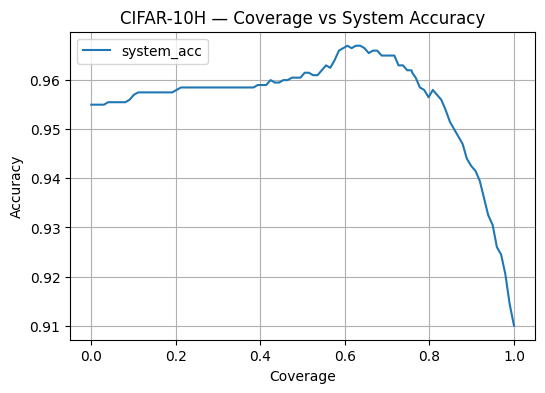

In [ ]:
curve_sorted = sorted(curve, key=lambda m: m["coverage"])

coverages = [m["coverage"] for m in curve_sorted]
system_accs = [m["system_acc"] for m in curve_sorted]
clf_accs = [m["classifier_nondeferred_acc"] for m in curve_sorted]
hum_accs = [m["human_deferred_acc"] for m in curve_sorted]

plt.figure(figsize=(6, 4))
plt.plot(coverages, system_accs, label="system_acc")
plt.xlabel("Coverage")
plt.ylabel("Accuracy")
plt.title("CIFAR-10H — Coverage vs System Accuracy")
plt.grid(True)
plt.legend()
save_current_figure("coverage_vs_system_accuracy.png", close=False)
plt.show()
plt.close()

## Human vs Classifier accuracy on the operational split

This plot compares the performance of the two decision-makers in the human-AI system as the **coverage** changes.


This plot is useful because it does not only show the final system performance, but also explains **how the workload is split** between model and human:

- when the classifier keeps only a small subset of very easy samples, its accuracy on non-deferred examples is expected to be very high
- as coverage increases, the classifier must also handle more difficult cases, so its non-deferred accuracy typically decreases
- at the same time, the human receives the deferred subset, which becomes smaller but usually harder, so the human accuracy on deferred samples may also change

Overall, this figure helps interpret whether the deferral mechanism is working in a meaningful way, that is, whether the classifier is retaining the easier and more reliable cases while delegating harder ones to the human expert.


Figure saved to: /content/figures/human_vs_classifier_operational_split.png


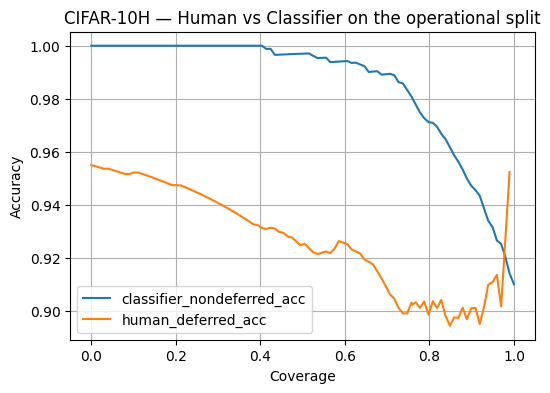

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(coverages, clf_accs, label="classifier_nondeferred_acc")
plt.plot(coverages, hum_accs, label="human_deferred_acc")
plt.xlabel("Coverage")
plt.ylabel("Accuracy")
plt.title("CIFAR-10H — Human vs Classifier on the operational split")
plt.grid(True)
plt.legend()
save_current_figure("human_vs_classifier_operational_split.png", close=False)
plt.show()
plt.close()

In [ ]:
defers = np.array(test_out["defers"])
preds = np.array(test_out["preds"])
labels = np.array(test_out["labels"])
hum_preds = np.array(test_out["hum_preds"])

print("Coverage:", 1.0 - defers.mean())
print("Number deferred:", int(defers.sum()))
print("Number non-deferred:", int((1 - defers).sum()))
print("System accuracy:", compute_deferral_metrics(test_out)["system_acc"])

Coverage: 0.7595000000000001
Number deferred: 481
Number non-deferred: 1519
System accuracy: 0.9615


In [ ]:
def denormalize(img_tensor):
    mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR_STD).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    return img.permute(1, 2, 0).numpy()


def show_examples_by_case(loader, test_out, case_fn, n=8, title="Examples"):
    idxs = [i for i in range(len(test_out["labels"])) if case_fn(i)]
    idxs = idxs[:n]

    if len(idxs) == 0:
        print("No example found.")
        return

    ds = loader.dataset

    plt.figure(figsize=(16, 2.8 * math.ceil(len(idxs) / 4) + 1))
    for plot_i, idx in enumerate(idxs, start=1):
        x, y, h = ds[idx]
        pred = int(test_out["preds"][idx])
        d = int(test_out["defers"][idx])
        score = float(test_out["rej_score"][idx])

        plt.subplot(math.ceil(len(idxs) / 4), 4, plot_i)
        plt.imshow(denormalize(x))
        plt.axis("off")
        plt.title(
            f"true={CLASS_NAMES[y]}\n"
            f"model={CLASS_NAMES[pred]}\n"
            f"human={CLASS_NAMES[h]}\n"
            f"defer={d} | score={score:.3f}"
        )

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

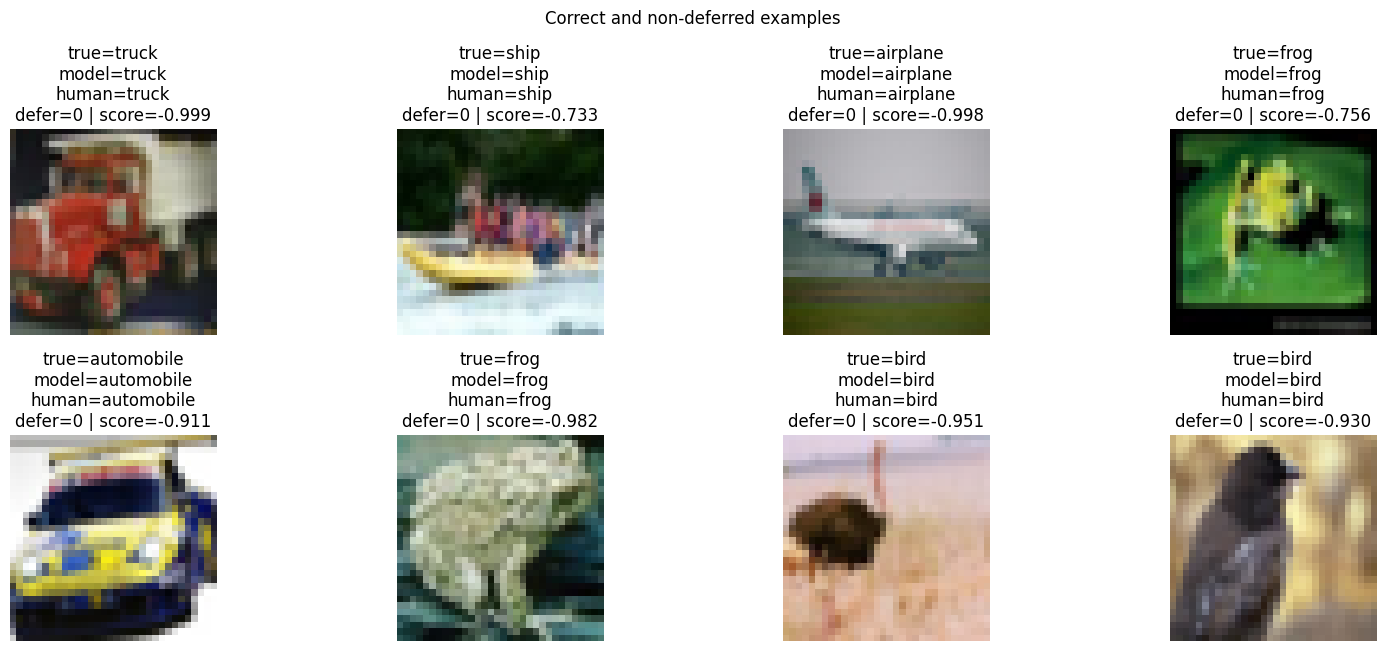

In [ ]:
show_examples_by_case(
    cifar10h_test_loader,
    test_out,
    case_fn=lambda i: test_out["defers"][i] == 0 and test_out["preds"][i] == test_out["labels"][i],
    n=8,
    title="Correct and non-deferred examples"
)

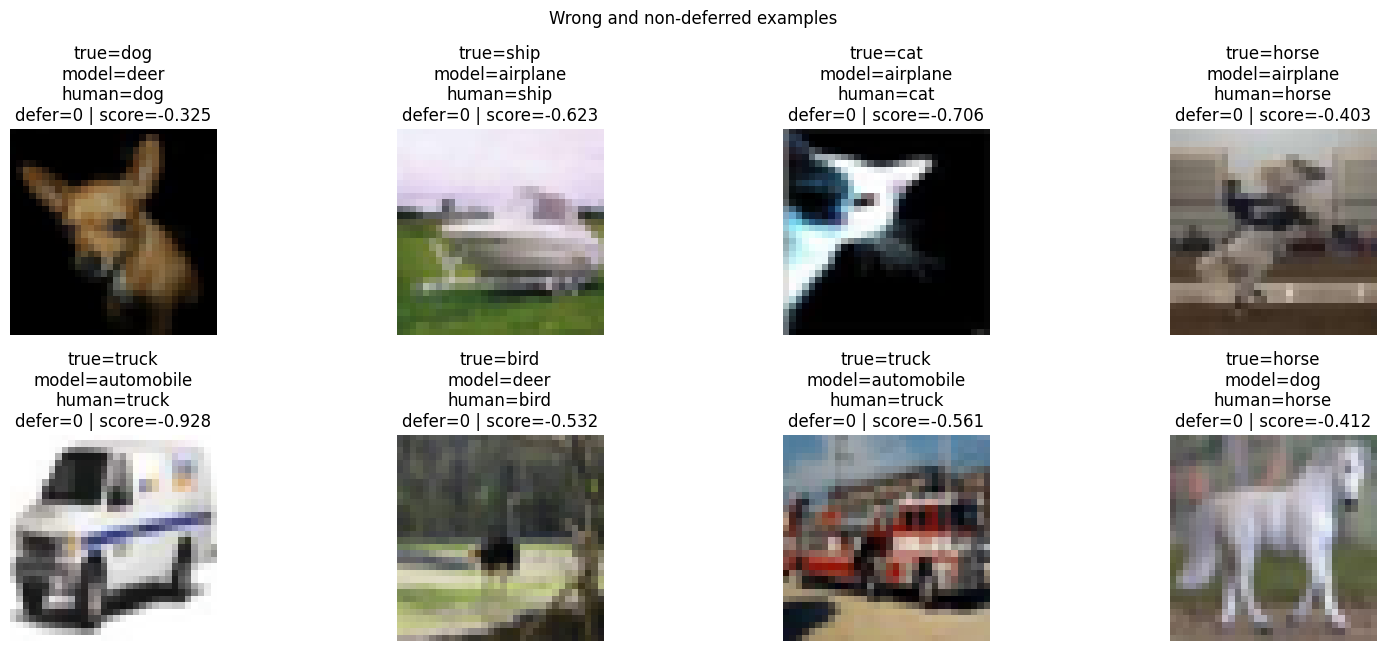

In [ ]:
show_examples_by_case(
    cifar10h_test_loader,
    test_out,
    case_fn=lambda i: test_out["defers"][i] == 0 and test_out["preds"][i] != test_out["labels"][i],
    n=8,
    title="Wrong and non-deferred examples"
)

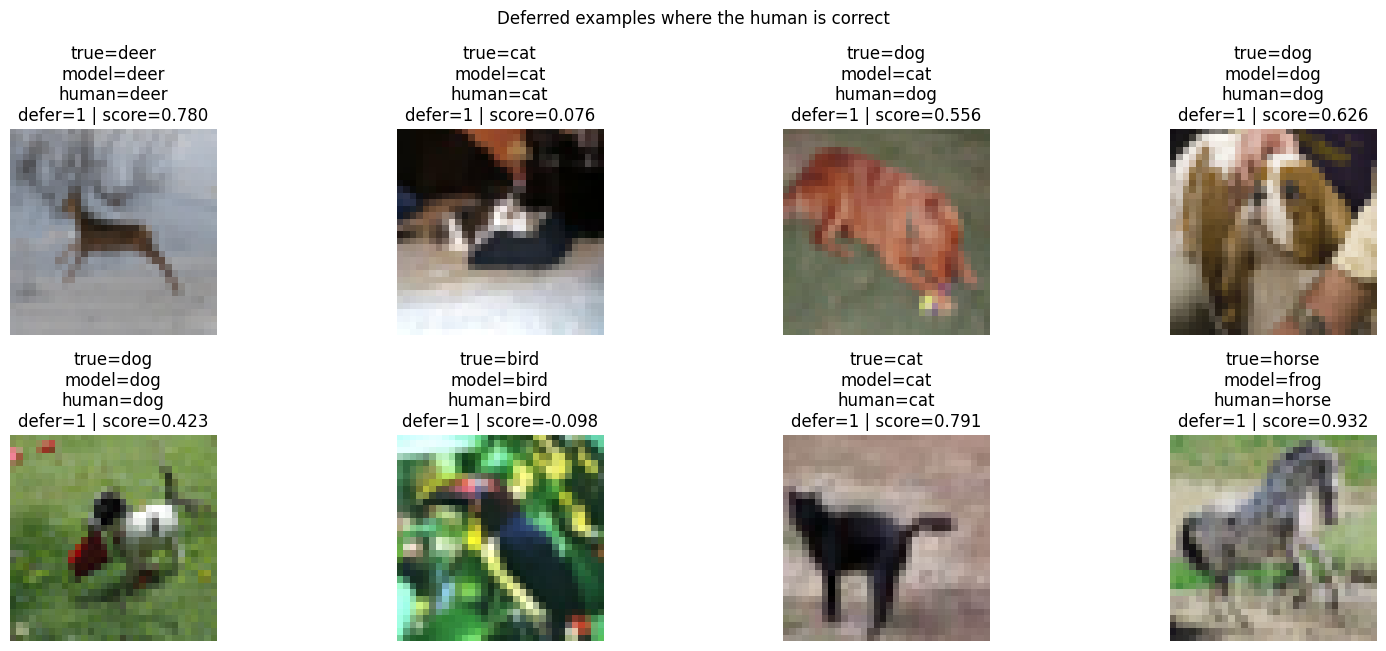

In [ ]:
show_examples_by_case(
    cifar10h_test_loader,
    test_out,
    case_fn=lambda i: test_out["defers"][i] == 1 and test_out["hum_preds"][i] == test_out["labels"][i],
    n=8,
    title="Deferred examples where the human is correct"
)

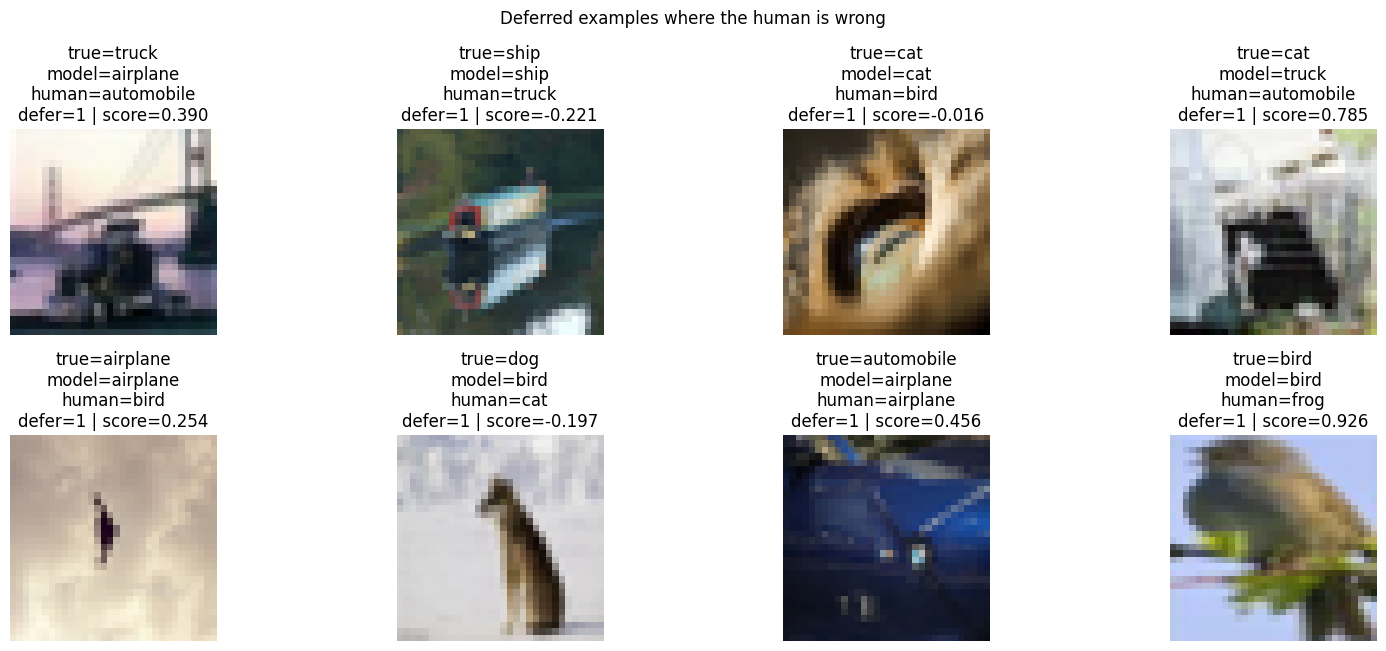

In [ ]:
show_examples_by_case(
    cifar10h_test_loader,
    test_out,
    case_fn=lambda i: test_out["defers"][i] == 1 and test_out["hum_preds"][i] != test_out["labels"][i],
    n=8,
    title="Deferred examples where the human is wrong"
)

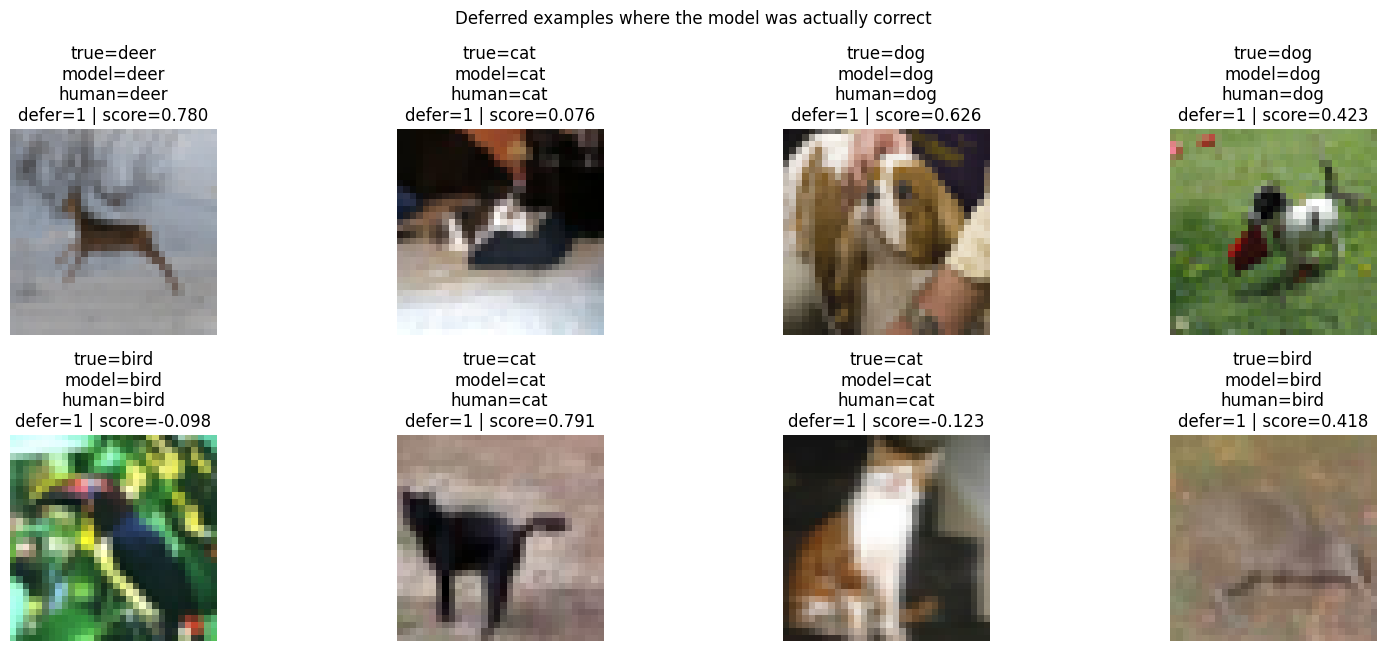

In [ ]:
show_examples_by_case(
    cifar10h_test_loader,
    test_out,
    case_fn=lambda i: test_out["defers"][i] == 1 and test_out["preds"][i] == test_out["labels"][i],
    n=8,
    title="Deferred examples where the model was actually correct"
)

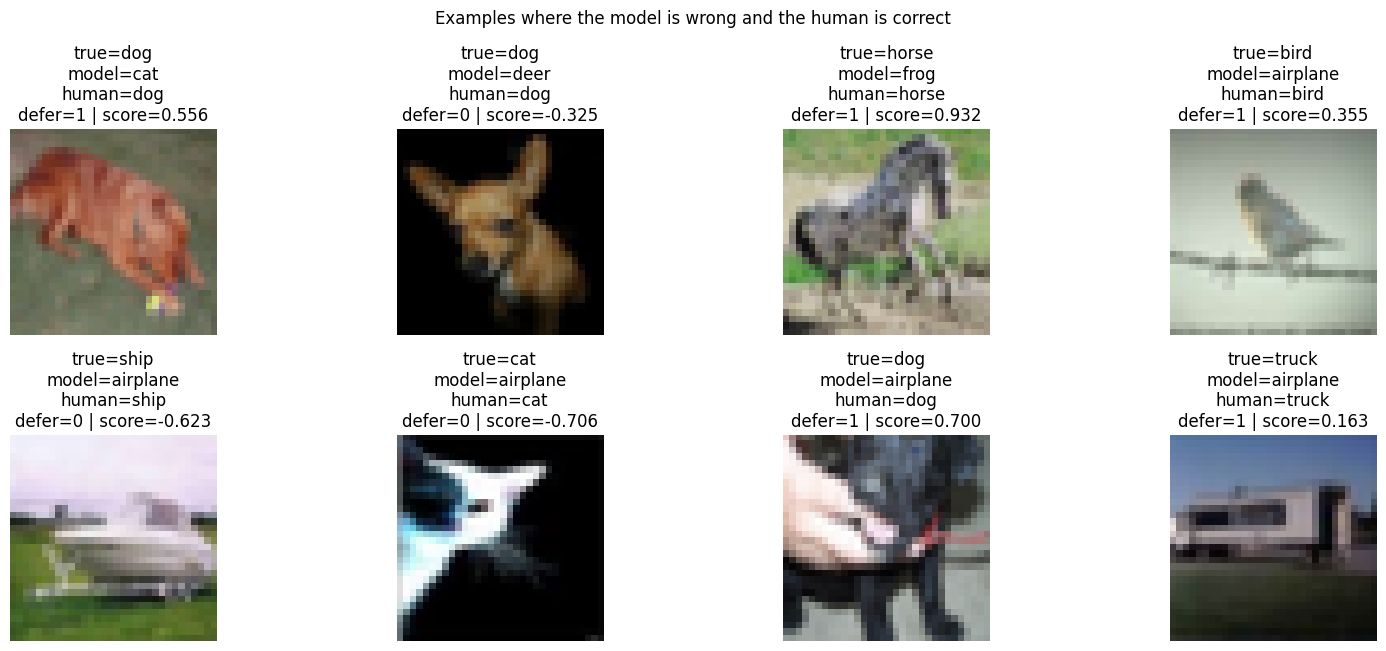

In [ ]:
show_examples_by_case(
    cifar10h_test_loader,
    test_out,
    case_fn=lambda i: test_out["preds"][i] != test_out["labels"][i] and test_out["hum_preds"][i] == test_out["labels"][i],
    n=8,
    title="Examples where the model is wrong and the human is correct"
)

Examples closest to the rejection threshold:


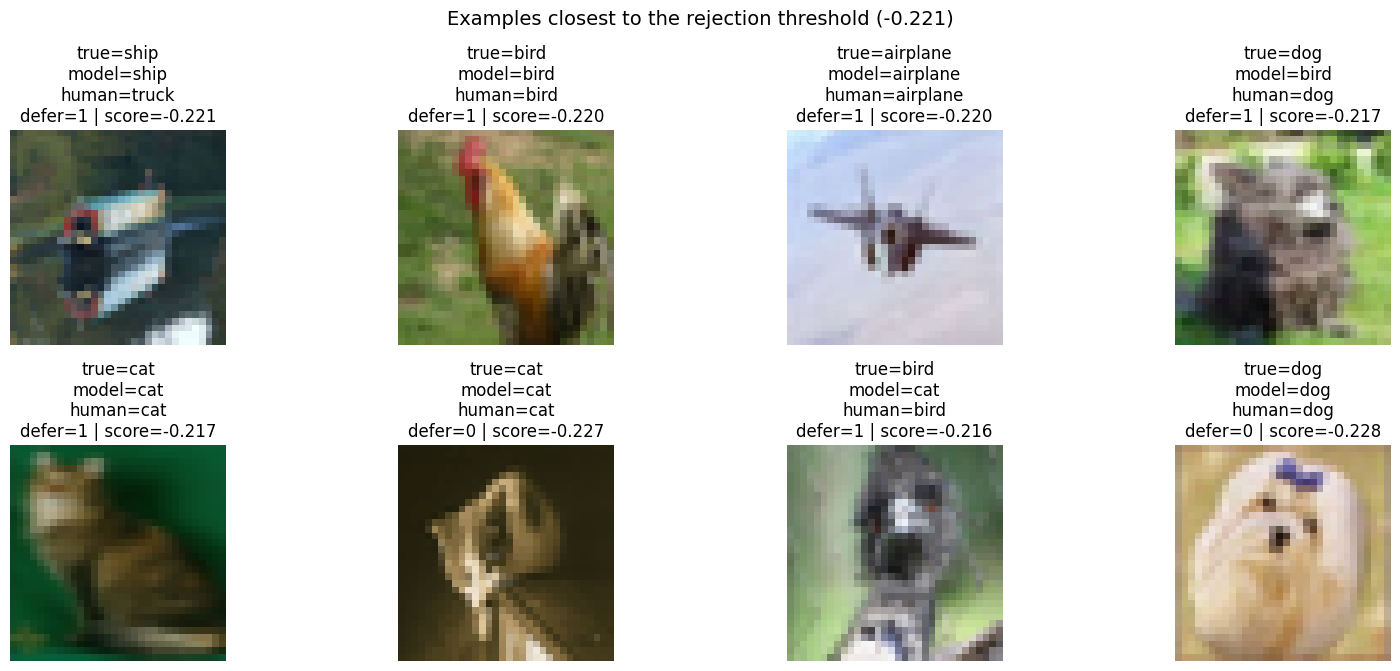

In [ ]:
def show_near_threshold_examples(loader, test_out, threshold, n=8):
    scores = np.asarray(test_out["rej_score"])
    idxs = np.argsort(np.abs(scores - threshold))[:n]

    ds = loader.dataset
    ncols = 4
    nrows = math.ceil(len(idxs) / ncols)
    plt.figure(figsize=(16, 3.4 * nrows))

    for plot_i, idx in enumerate(idxs, start=1):
        x, y, h = ds[idx]
        pred = int(test_out["preds"][idx])
        d = int(test_out["defers"][idx])
        score = float(test_out["rej_score"][idx])

        plt.subplot(nrows, ncols, plot_i)
        plt.imshow(denormalize(x))
        plt.axis("off")
        plt.title(
            f"true={CLASS_NAMES[y]}\n"
            f"model={CLASS_NAMES[pred]}\n"
            f"human={CLASS_NAMES[h]}\n"
            f"defer={d} | score={score:.3f}"
        )

    plt.suptitle(f"Examples closest to the rejection threshold ({threshold:.3f})", fontsize=14)
    plt.tight_layout()
    plt.show()


print("Examples closest to the rejection threshold:")
show_near_threshold_examples(
    cifar10h_test_loader,
    test_out,
    threshold=rs.threshold_rej,
    n=8
)

Highest rejection score examples:


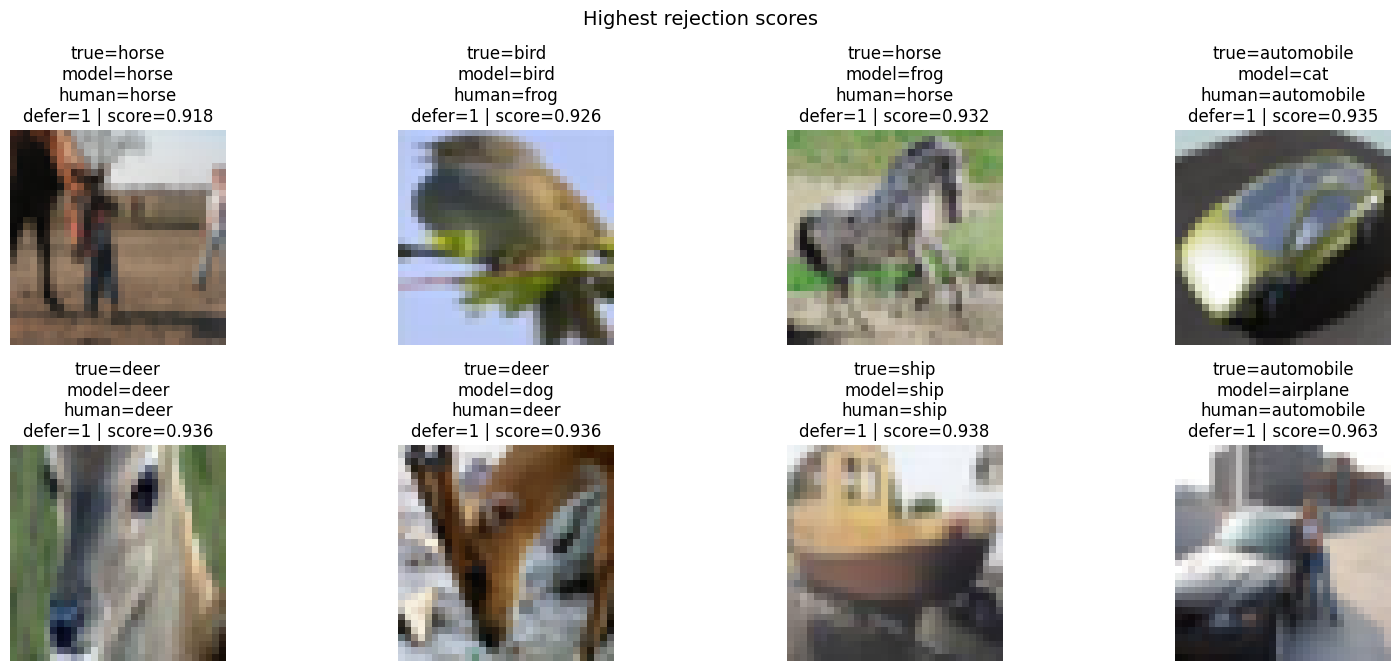

In [ ]:
def show_extreme_score_examples(loader, test_out, n=8, highest=True):
    scores = np.asarray(test_out["rej_score"])
    idxs = np.argsort(scores)
    idxs = idxs[-n:] if highest else idxs[:n]

    ds = loader.dataset
    ncols = 4
    nrows = math.ceil(len(idxs) / ncols)
    plt.figure(figsize=(16, 3.4 * nrows))

    for plot_i, idx in enumerate(idxs, start=1):
        x, y, h = ds[idx]
        pred = int(test_out["preds"][idx])
        d = int(test_out["defers"][idx])
        score = float(test_out["rej_score"][idx])

        plt.subplot(nrows, ncols, plot_i)
        plt.imshow(denormalize(x))
        plt.axis("off")
        plt.title(
            f"true={CLASS_NAMES[y]}\n"
            f"model={CLASS_NAMES[pred]}\n"
            f"human={CLASS_NAMES[h]}\n"
            f"defer={d} | score={score:.3f}"
        )

    title = "Highest rejection scores" if highest else "Lowest rejection scores"
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


print("Highest rejection score examples:")
show_extreme_score_examples(
    cifar10h_test_loader,
    test_out,
    n=8,
    highest=True
)

In [ ]:
summary_payload = {
    "run_id": RUN_ID,
    "selected_alpha": rs.alpha,
    "selected_threshold": rs.threshold_rej,
    "freeze_backbone": FREEZE_BACKBONE,
    "classifier_all_acc": metrics["classifier_all_acc"],
    "human_all_acc": metrics["human_all_acc"],
    "coverage": metrics["coverage"],
    "classifier_nondeferred_acc": metrics["classifier_nondeferred_acc"],
    "human_deferred_acc": metrics["human_deferred_acc"],
    "system_acc": metrics["system_acc"],
    "num_deferred": int(np.sum(test_out["defers"] == 1)),
    "num_nondeferred": int(np.sum(test_out["defers"] == 0)),
}

save_metrics_json("summary_metrics.json", summary_payload)
print(summary_payload)

Metrics JSON saved to: /content/results/summary_metrics.json
{'run_id': '20260409_210507', 'selected_alpha': 1.0, 'selected_threshold': -0.22143488580530332, 'freeze_backbone': True, 'classifier_all_acc': 0.91, 'human_all_acc': 0.955, 'coverage': np.float64(0.7595000000000001), 'classifier_nondeferred_acc': 0.9802501645819618, 'human_deferred_acc': 0.9022869022869023, 'system_acc': 0.9615, 'num_deferred': 481, 'num_nondeferred': 1519}
